# Arquitectura MLP — Iteración Medium orientada a RMSE en USD

Esta versión mantiene la estructura del notebook original, fija las semillas para hacer comparaciones reproducibles y selecciona los hiperparámetros según el **RMSE real en USD** sobre validación. El objetivo de referencia es RMSE < $30,000.


In [1]:
import os
import random
import time
from itertools import product

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Ayuda a la reproducibilidad en CUDA (puede reducir un poco el rendimiento)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando device: {device}')

os.makedirs('reports', exist_ok=True)
os.makedirs('models', exist_ok=True)

X_train = np.load('data/X_train_processed.npy')
X_val = np.load('data/X_val_processed.npy')
y_train = np.load('data/y_train.npy')
y_val = np.load('data/y_val.npy')

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')
print(f'y_train: {y_train.shape}, y_val: {y_val.shape}')


Usando device: cpu
X_train: (934, 223), X_val: (234, 223)
y_train: (934,), y_val: (234,)


## Estrategia de división de datos


In [2]:
print('Tamaño de validación:', X_val.shape[0],
      f'({X_val.shape[0]/(X_train.shape[0]+X_val.shape[0])*100:.1f}% del total)')


Tamaño de validación: 234 (20.0% del total)


## Arquitecturas de red consideradas


In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.0, batch_norm=False):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

ARCHITECTURES = {
    'shallow': [64],
    'medium': [128, 64],
    'deep': [256, 128, 64, 32],
}

for name, layers in ARCHITECTURES.items():
    m = MLP(X_train.shape[1], layers)
    n_params = sum(p.numel() for p in m.parameters())
    print(f'{name:10s} {str(layers):20s} -> {n_params:,} parámetros')


shallow    [64]                 -> 14,401 parámetros
medium     [128, 64]            -> 36,993 parámetros
deep       [256, 128, 64, 32]   -> 100,609 parámetros


## Funciones de evaluación y entrenamiento

El entrenamiento continúa usando `MSELoss` sobre `log1p(SalePrice)`, como en tu notebook original. La diferencia es que durante validación también se revierten las predicciones con `expm1` y se calcula el RMSE directamente en dólares.


In [4]:
def rmse_usd_from_log(y_true_log, y_pred_log):
    y_true_usd = np.expm1(np.asarray(y_true_log).reshape(-1))
    y_pred_usd = np.expm1(np.asarray(y_pred_log).reshape(-1))
    return float(np.sqrt(np.mean((y_pred_usd - y_true_usd) ** 2)))


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_model(hidden_layers, hp, X_train, y_train, X_val, y_val,
                verbose=True, seed=SEED):
    set_seed(seed)

    model = MLP(
        X_train.shape[1], hidden_layers,
        dropout=hp['dropout'],
        batch_norm=hp['batch_norm']
    ).to(device)

    opt = torch.optim.Adam(
        model.parameters(),
        lr=hp['lr'],
        weight_decay=hp['weight_decay']
    )
    loss_fn = nn.MSELoss()

    Xtr_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    ytr_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1).to(device)
    Xva_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    yva_t = torch.tensor(y_val, dtype=torch.float32).reshape(-1).to(device)

    generator = torch.Generator()
    generator.manual_seed(seed)
    train_loader = DataLoader(
        TensorDataset(Xtr_t, ytr_t),
        batch_size=hp['batch_size'],
        shuffle=True,
        generator=generator
    )

    history = {
        'train_rmse_log': [],
        'val_rmse_log': [],
        'val_rmse_usd': []
    }

    # Early stopping sigue RMSE log porque es la métrica directamente
    # asociada a la función de pérdida. Guardamos también el RMSE USD.
    best_val_rmse_log = float('inf')
    best_val_rmse_usd = float('inf')
    best_state = None
    best_epoch = -1
    epochs_no_improve = 0

    for epoch in range(hp['max_epochs']):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            train_pred = model(Xtr_t)
            val_pred = model(Xva_t)
            train_rmse_log = torch.sqrt(loss_fn(train_pred, ytr_t)).item()
            val_rmse_log = torch.sqrt(loss_fn(val_pred, yva_t)).item()
            val_pred_np = val_pred.detach().cpu().numpy()

        val_rmse_usd = rmse_usd_from_log(y_val, val_pred_np)

        history['train_rmse_log'].append(train_rmse_log)
        history['val_rmse_log'].append(val_rmse_log)
        history['val_rmse_usd'].append(val_rmse_usd)

        if val_rmse_log < best_val_rmse_log:
            best_val_rmse_log = val_rmse_log
            best_val_rmse_usd = val_rmse_usd
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and epoch % 20 == 0:
            print(f'  epoch {epoch:3d} | train RMSE(log)={train_rmse_log:.4f} | '
                  f'val RMSE(log)={val_rmse_log:.4f} | val RMSE(USD)=${val_rmse_usd:,.2f}')

        if epochs_no_improve >= hp['patience']:
            if verbose:
                print(f'  Early stopping en epoch {epoch}; mejor epoch={best_epoch}')
            break

    model.load_state_dict(best_state)
    model.to(device)

    # Recalcular ambas métricas usando exactamente el estado restaurado.
    model.eval()
    with torch.no_grad():
        final_val_pred = model(Xva_t).detach().cpu().numpy()
    final_val_rmse_log = float(np.sqrt(np.mean((final_val_pred.reshape(-1) - np.asarray(y_val).reshape(-1)) ** 2)))
    final_val_rmse_usd = rmse_usd_from_log(y_val, final_val_pred)

    return model, history, final_val_rmse_log, final_val_rmse_usd, best_epoch


## Comparación inicial de arquitecturas

Primero comparamos `shallow`, `medium` y `deep` con los mismos hiperparámetros. Esto permite verificar si una red más profunda realmente aporta una mejora.


In [5]:
BASE_HP = {
    'lr': 5e-4,
    'weight_decay': 1e-4,
    'batch_size': 32,
    'max_epochs': 200,
    'patience': 15,
    'dropout': 0.1,
    'batch_norm': True,
}

architecture_results = {}
for name, layers in ARCHITECTURES.items():
    print(f'\nEntrenando arquitectura {name!r} {layers}...')
    model, history, rmse_log, rmse_usd, best_epoch = train_model(
        layers, BASE_HP, X_train, y_train, X_val, y_val, verbose=False
    )
    architecture_results[name] = {
        'model': model,
        'history': history,
        'val_rmse_log': rmse_log,
        'val_rmse_usd': rmse_usd,
        'best_epoch': best_epoch,
    }
    print(f'  RMSE log: {rmse_log:.4f} | RMSE USD: ${rmse_usd:,.2f}')

architecture_summary = pd.DataFrame([
    {
        'Arquitectura': name,
        'Capas ocultas': str(ARCHITECTURES[name]),
        'Val RMSE (log)': r['val_rmse_log'],
        'Val RMSE (USD)': r['val_rmse_usd'],
        'Mejor época': r['best_epoch'],
    }
    for name, r in architecture_results.items()
]).sort_values('Val RMSE (USD)')

architecture_summary



Entrenando arquitectura 'shallow' [64]...
  RMSE log: 1.3190 | RMSE USD: $7,895,837,592.94

Entrenando arquitectura 'medium' [128, 64]...
  RMSE log: 0.5010 | RMSE USD: $75,090.26

Entrenando arquitectura 'deep' [256, 128, 64, 32]...
  RMSE log: 0.3156 | RMSE USD: $55,991.75


,Arquitectura,Capas ocultas,Val RMSE (log),Val RMSE (USD),Mejor época
2,deep,"[256, 128, 64, 32]",0.315618,5.599175e+04,74
1,medium,"[128, 64]",0.501040,7.509026e+04,101
0,shallow,[64],1.319032,7.895838e+09,44


## Grid search sobre la arquitectura Medium

Aquí se fija `medium = [128, 64]`. Se incluye `dropout=0.0` porque BatchNorm y weight decay ya proporcionan regularización y queremos comprobar si el dropout estaba perjudicando el ajuste.


In [6]:
FIXED_ARCH_NAME = 'medium'
FIXED_ARCH = ARCHITECTURES[FIXED_ARCH_NAME]

param_grid = {
    'lr': [1e-3, 5e-4, 1e-4],
    'dropout': [0.0, 0.1, 0.2],
    'weight_decay': [0.0, 1e-4, 1e-3],
}

combinations = list(product(
    param_grid['lr'],
    param_grid['dropout'],
    param_grid['weight_decay']
))
print(f'Arquitectura fija: {FIXED_ARCH_NAME} {FIXED_ARCH}')
print(f'Total de combinaciones: {len(combinations)}')


Arquitectura fija: medium [128, 64]
Total de combinaciones: 27


In [7]:
grid_results = []
start_time = time.time()

for i, (lr, dropout, wd) in enumerate(combinations):
    hp = {
        'lr': lr,
        'dropout': dropout,
        'weight_decay': wd,
        'batch_size': 32,
        'max_epochs': 250,
        'patience': 20,
        'batch_norm': True,
    }

    t0 = time.time()
    model, history, val_rmse_log, val_rmse_usd, best_epoch = train_model(
        FIXED_ARCH, hp, X_train, y_train, X_val, y_val,
        verbose=False, seed=SEED
    )
    elapsed = time.time() - t0

    grid_results.append({
        'lr': lr,
        'dropout': dropout,
        'weight_decay': wd,
        'val_rmse_log': val_rmse_log,
        'val_rmse_usd': val_rmse_usd,
        'best_epoch': best_epoch,
        'epochs_trained': len(history['val_rmse_log']),
        'time_sec': round(elapsed, 1),
    })

    print(f'[{i+1:02d}/{len(combinations)}] lr={lr:.0e} | dropout={dropout:.1f} | '
          f'wd={wd:.0e} -> RMSE(log)={val_rmse_log:.4f} | '
          f'RMSE(USD)=${val_rmse_usd:,.2f}')

total_time = time.time() - start_time
print(f'\nTiempo total: {total_time/60:.1f} minutos')


[01/27] lr=1e-03 | dropout=0.0 | wd=0e+00 -> RMSE(log)=0.6107 | RMSE(USD)=$1,331,356.32
[02/27] lr=1e-03 | dropout=0.0 | wd=1e-04 -> RMSE(log)=0.5022 | RMSE(USD)=$185,350.70
[03/27] lr=1e-03 | dropout=0.0 | wd=1e-03 -> RMSE(log)=0.3821 | RMSE(USD)=$99,804.32
[04/27] lr=1e-03 | dropout=0.1 | wd=0e+00 -> RMSE(log)=0.4096 | RMSE(USD)=$109,555.72
[05/27] lr=1e-03 | dropout=0.1 | wd=1e-04 -> RMSE(log)=0.5339 | RMSE(USD)=$78,692.10
[06/27] lr=1e-03 | dropout=0.1 | wd=1e-03 -> RMSE(log)=0.4726 | RMSE(USD)=$95,191.67
[07/27] lr=1e-03 | dropout=0.2 | wd=0e+00 -> RMSE(log)=0.4467 | RMSE(USD)=$76,170.12
[08/27] lr=1e-03 | dropout=0.2 | wd=1e-04 -> RMSE(log)=0.5472 | RMSE(USD)=$88,449.27
[09/27] lr=1e-03 | dropout=0.2 | wd=1e-03 -> RMSE(log)=0.4571 | RMSE(USD)=$91,487.97
[10/27] lr=5e-04 | dropout=0.0 | wd=0e+00 -> RMSE(log)=0.5288 | RMSE(USD)=$88,816.25
[11/27] lr=5e-04 | dropout=0.0 | wd=1e-04 -> RMSE(log)=0.4106 | RMSE(USD)=$94,353.49
[12/27] lr=5e-04 | dropout=0.0 | wd=1e-03 -> RMSE(log)=0.424

## Resultados del grid search

La tabla se ordena por **RMSE en USD**, que es la métrica que quieres llevar por debajo de $30,000.


In [8]:
results_df = pd.DataFrame(grid_results).sort_values('val_rmse_usd').reset_index(drop=True)
results_df


,lr,dropout,weight_decay,val_rmse_log,val_rmse_usd,best_epoch,epochs_trained,time_sec
0,0.0005,0.1,0.0001,0.501040,7.509026e+04,101,122,4.6
1,0.0010,0.2,0.0000,0.446676,7.617012e+04,101,122,4.7
2,0.0010,0.1,0.0001,0.533932,7.869210e+04,43,64,2.6
3,0.0005,0.1,0.0000,0.617091,8.048822e+04,43,64,2.4
4,0.0005,0.2,0.0001,0.535246,8.771420e+04,74,95,3.7
5,0.0010,0.2,0.0001,0.547177,8.844927e+04,43,64,2.4
6,0.0005,0.0,0.0000,0.528810,8.881625e+04,43,64,2.3
7,0.0005,0.1,0.0010,0.616660,8.911287e+04,43,64,2.4
8,0.0005,0.0,0.0010,0.424179,8.953074e+04,114,135,4.9
9,0.0005,0.2,0.0010,0.539196,9.106505e+04,74,95,3.6


In [9]:
best_config = results_df.iloc[0]
print('Mejor configuración según RMSE en USD:')
print(best_config)

best_usd = best_config['val_rmse_usd']
if best_usd < 30000:
    print(f'\nObjetivo alcanzado: RMSE = ${best_usd:,.2f} < $30,000')
else:
    print(f'\nObjetivo todavía no alcanzado: RMSE = ${best_usd:,.2f}')
    print(f'Faltan ${best_usd - 30000:,.2f} para bajar de $30,000.')


Mejor configuración según RMSE en USD:
lr                    0.000500
dropout               0.100000
weight_decay          0.000100
val_rmse_log          0.501040
val_rmse_usd      75090.264932
best_epoch          101.000000
epochs_trained      122.000000
time_sec              4.600000
Name: 0, dtype: float64

Objetivo todavía no alcanzado: RMSE = $75,090.26
Faltan $45,090.26 para bajar de $30,000.


## Efecto de los hiperparámetros


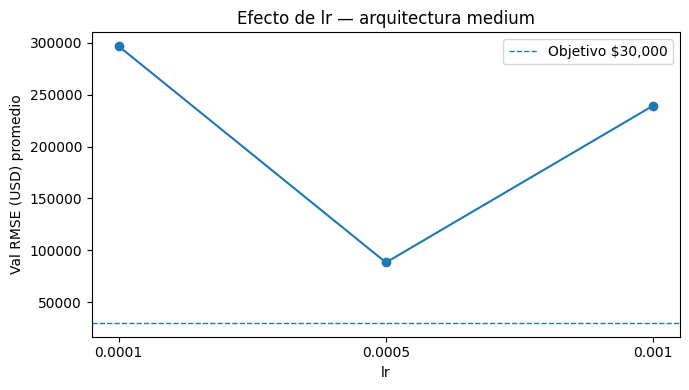

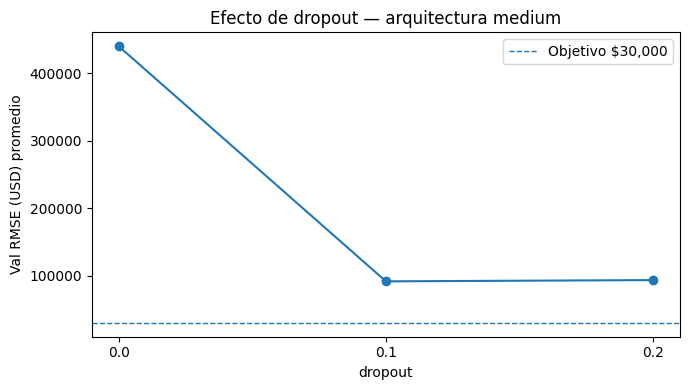

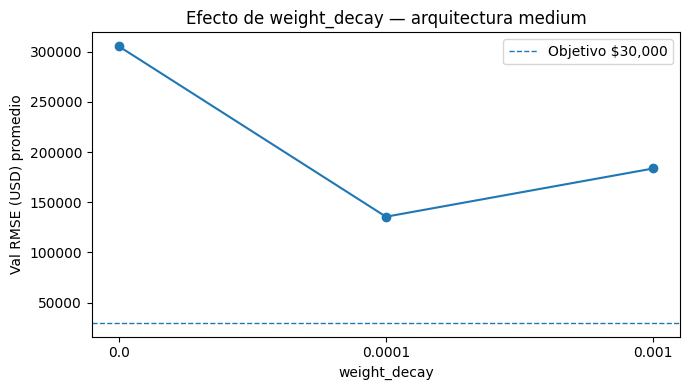

In [10]:
for param in ['lr', 'dropout', 'weight_decay']:
    grouped = results_df.groupby(param)['val_rmse_usd'].mean().sort_index()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(grouped.index.astype(str), grouped.values, marker='o', linewidth=1.5)
    ax.axhline(30000, linestyle='--', linewidth=1, label='Objetivo $30,000')
    ax.set_xlabel(param)
    ax.set_ylabel('Val RMSE (USD) promedio')
    ax.set_title(f'Efecto de {param} — arquitectura medium')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'reports/medium_efecto_{param}.png', dpi=110)
    plt.show()


## Reentrenar la mejor configuración

Como las semillas están fijadas, esta ejecución debería reproducir el resultado del grid con diferencias mínimas o nulas.


In [11]:
best_hp = {
    'lr': float(best_config['lr']),
    'dropout': float(best_config['dropout']),
    'weight_decay': float(best_config['weight_decay']),
    'batch_size': 32,
    'max_epochs': 250,
    'patience': 20,
    'batch_norm': True,
}

best_model, best_history, best_val_rmse_log, best_val_rmse_usd, best_epoch = train_model(
    FIXED_ARCH, best_hp, X_train, y_train, X_val, y_val,
    verbose=True, seed=SEED
)

print(f'\nMejor época: {best_epoch}')
print(f'RMSE validación (log): {best_val_rmse_log:.4f}')
print(f'RMSE validación (USD): ${best_val_rmse_usd:,.2f}')


  epoch   0 | train RMSE(log)=11.6777 | val RMSE(log)=11.6952 | val RMSE(USD)=$199,941.95
  epoch  20 | train RMSE(log)=1.3868 | val RMSE(log)=1.7423 | val RMSE(USD)=$155,544.62
  epoch  40 | train RMSE(log)=0.5069 | val RMSE(log)=0.7649 | val RMSE(USD)=$112,823.45
  epoch  60 | train RMSE(log)=0.3732 | val RMSE(log)=0.6632 | val RMSE(USD)=$162,613.28
  epoch  80 | train RMSE(log)=0.2749 | val RMSE(log)=0.5544 | val RMSE(USD)=$93,412.81
  epoch 100 | train RMSE(log)=0.2975 | val RMSE(log)=0.5528 | val RMSE(USD)=$81,327.45
  epoch 120 | train RMSE(log)=0.4744 | val RMSE(log)=0.6780 | val RMSE(USD)=$87,663.98
  Early stopping en epoch 121; mejor epoch=101

Mejor época: 101
RMSE validación (log): 0.5010
RMSE validación (USD): $75,090.26


## Curvas del mejor modelo


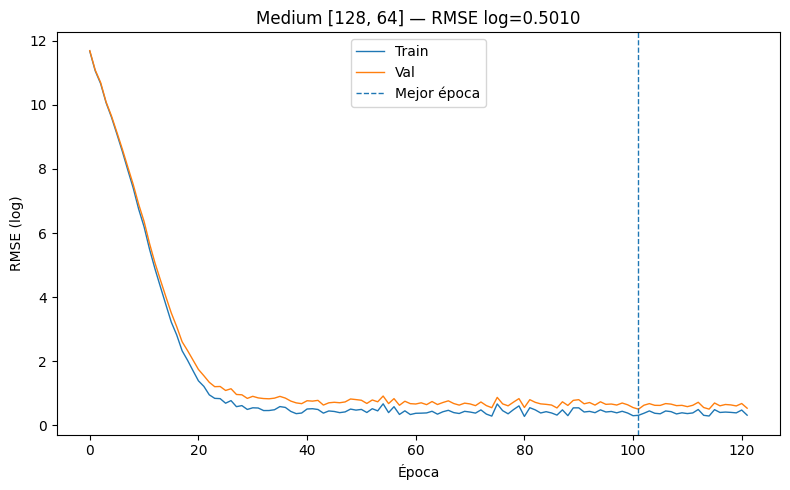

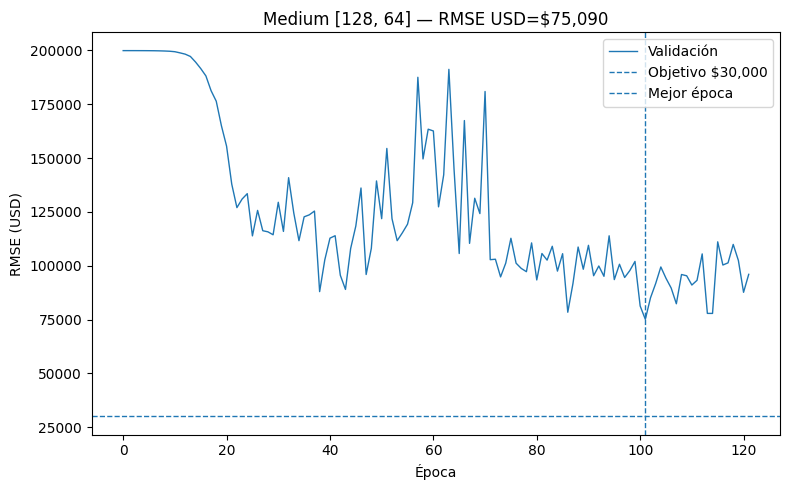

In [12]:
epochs = range(len(best_history['train_rmse_log']))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, best_history['train_rmse_log'], linewidth=1, label='Train')
ax.plot(epochs, best_history['val_rmse_log'], linewidth=1, label='Val')
ax.axvline(best_epoch, linestyle='--', linewidth=1, label='Mejor época')
ax.set_xlabel('Época')
ax.set_ylabel('RMSE (log)')
ax.set_title(f'Medium {FIXED_ARCH} — RMSE log={best_val_rmse_log:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('reports/medium_mejor_modelo_rmse_log.png', dpi=110)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, best_history['val_rmse_usd'], linewidth=1, label='Validación')
ax.axhline(30000, linestyle='--', linewidth=1, label='Objetivo $30,000')
ax.axvline(best_epoch, linestyle='--', linewidth=1, label='Mejor época')
ax.set_xlabel('Época')
ax.set_ylabel('RMSE (USD)')
ax.set_title(f'Medium {FIXED_ARCH} — RMSE USD=${best_val_rmse_usd:,.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('reports/medium_mejor_modelo_rmse_usd.png', dpi=110)
plt.show()


## Evaluación visual de predicciones


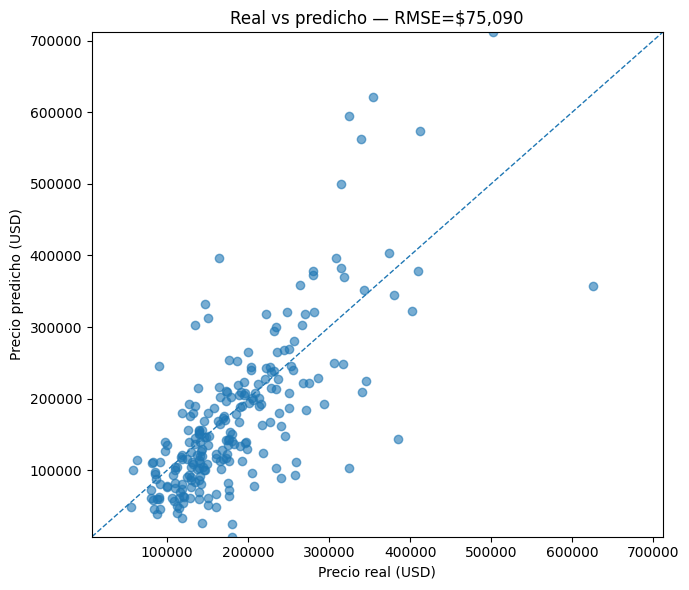

In [13]:
best_model.eval()
Xva_t = torch.tensor(X_val, dtype=torch.float32).to(device)
with torch.no_grad():
    val_pred_log = best_model(Xva_t).cpu().numpy()

val_pred_usd = np.expm1(val_pred_log.reshape(-1))
val_true_usd = np.expm1(np.asarray(y_val).reshape(-1))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(val_true_usd, val_pred_usd, alpha=0.6)
lims = [min(val_true_usd.min(), val_pred_usd.min()),
        max(val_true_usd.max(), val_pred_usd.max())]
ax.plot(lims, lims, linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Precio real (USD)')
ax.set_ylabel('Precio predicho (USD)')
ax.set_title(f'Real vs predicho — RMSE=${best_val_rmse_usd:,.0f}')
plt.tight_layout()
plt.savefig('reports/medium_real_vs_predicho.png', dpi=110)
plt.show()


## Guardar modelo y resultados


In [14]:
torch.save({
    'model_state_dict': best_model.state_dict(),
    'architecture_name': FIXED_ARCH_NAME,
    'architecture': FIXED_ARCH,
    'hyperparams': best_hp,
    'seed': SEED,
    'best_epoch': best_epoch,
    'val_rmse_log': best_val_rmse_log,
    'val_rmse_usd': best_val_rmse_usd,
}, 'models/best_mlp_medium.pt')

results_df.to_csv('reports/grid_search_medium_resultados.csv', index=False)
architecture_summary.to_csv('reports/comparacion_arquitecturas.csv', index=False)

print('Modelo guardado en models/best_mlp_medium.pt')
print('Grid guardado en reports/grid_search_medium_resultados.csv')
print('Comparación guardada en reports/comparacion_arquitecturas.csv')


Modelo guardado en models/best_mlp_medium.pt
Grid guardado en reports/grid_search_medium_resultados.csv
Comparación guardada en reports/comparacion_arquitecturas.csv


## Interpretación

- El modelo se entrena sobre `log1p(SalePrice)`, igual que en el flujo original.
- El RMSE en USD se calcula **después** de aplicar `expm1` a valores reales y predicciones; no se usa `expm1(RMSE_log)`.
- El grid search se realiza sobre `medium = [128, 64]` y se ordena por RMSE en USD.
- Si esta versión todavía no baja de $30,000, el siguiente experimento debería revisar el objetivo/loss y no simplemente aumentar la profundidad de la red.
